In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [8]:
df = pd.read_csv("../data/rainfall_dataset.csv")


In [9]:
# Remove Total row
df = df[df["Month"] != "Total"].reset_index(drop=True)

In [10]:
# Create time index (April → March)
df["time"] = pd.date_range(start="2016-04-01", periods=len(df), freq="MS")
df.set_index("time", inplace=True)

In [11]:
# Build continuous series using averages
wet_cols = [c for c in df.columns if "Wet days" in c and "10yr" not in c]
rain_cols = [c for c in df.columns if "Rainfall" in c and "10yr" not in c]

df["WetDays"] = df[wet_cols].mean(axis=1, skipna=True)
df["Rainfall"] = df[rain_cols].mean(axis=1, skipna=True)

ts = df[["WetDays", "Rainfall"]]


Summary statistics:
         WetDays    Rainfall
count  12.000000   12.000000
mean   15.980556  442.771991
std     5.937108  259.135095
min     6.333333   80.000000
25%    10.197917  218.552083
50%    18.294444  469.766667
75%    20.775000  604.350000
max    22.700000  848.500000


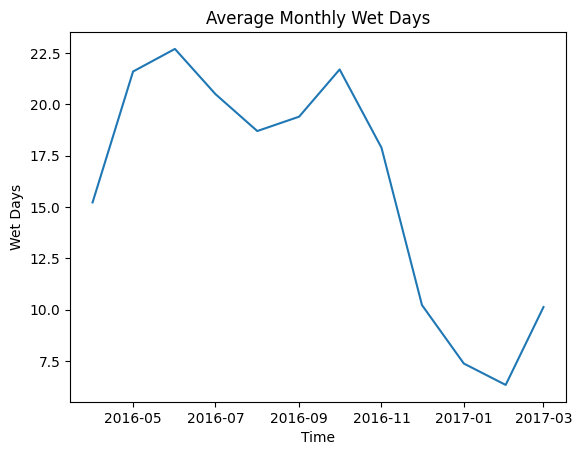

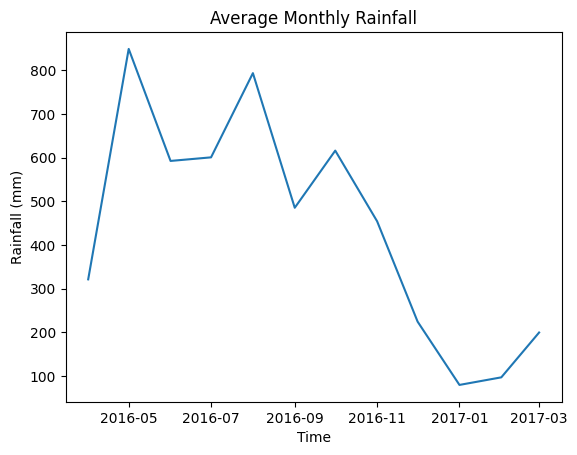

In [12]:
# 2. Exploratory Data Analysis
print("Summary statistics:")
print(ts.describe())

plt.figure()
plt.plot(ts.index, ts["WetDays"])
plt.title("Average Monthly Wet Days")
plt.xlabel("Time")
plt.ylabel("Wet Days")
plt.show()

plt.figure()
plt.plot(ts.index, ts["Rainfall"])
plt.title("Average Monthly Rainfall")
plt.xlabel("Time")
plt.ylabel("Rainfall (mm)")
plt.show()


In [13]:
# 3. ARIMAX (SARIMAX) Models
# Wet Days model (Rainfall as exogenous)
wet_model = SARIMAX(
    ts["WetDays"],
    exog=ts[["Rainfall"]],
    order=(1,1,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("\nWet Days Model Summary:")
print(wet_model.summary())


Wet Days Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                            WetDays   No. Observations:                   12
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                   0.000
Date:                            Sat, 17 Jan 2026   AIC                             12.000
Time:                                    19:08:56   BIC                                nan
Sample:                                04-01-2016   HQIC                               nan
                                     - 03-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Rainfall       0.0099         -0       -inf      0.000       0.010       0.010
ar.L1     

C:\Users\Lenovo\PycharmProjects\STEMS\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Lenovo\PycharmProjects\STEMS\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Lenovo\PycharmProjects\STEMS\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\Lenovo\PycharmProjects\STEMS\.venv\Lib\site-packages\statsmodels\tools\eval_measures.py:414: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + np.log(nobs) * df_modelwc
C:\Users\Lenovo\PycharmProjects\STEMS\

In [14]:
# Rainfall model (Wet Days as exogenous)
rain_model = SARIMAX(
    ts["Rainfall"],
    exog=ts[["WetDays"]],
    order=(1,1,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("\nRainfall Model Summary:")
print(rain_model.summary())



Rainfall Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                           Rainfall   No. Observations:                   12
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                   0.000
Date:                            Sat, 17 Jan 2026   AIC                             12.000
Time:                                    19:09:33   BIC                                nan
Sample:                                04-01-2016   HQIC                               nan
                                     - 03-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
WetDays       39.0430         -0       -inf      0.000      39.043      39.043
ar.L1     

C:\Users\Lenovo\PycharmProjects\STEMS\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Lenovo\PycharmProjects\STEMS\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Lenovo\PycharmProjects\STEMS\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\Lenovo\PycharmProjects\STEMS\.venv\Lib\site-packages\statsmodels\tools\eval_measures.py:414: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + np.log(nobs) * df_modelwc
C:\Users\Lenovo\PycharmProjects\STEMS\

In [15]:
# 4. Forecast next month
last_wet = ts["WetDays"].iloc[-1]
last_rain = ts["Rainfall"].iloc[-1]

wet_forecast = wet_model.get_forecast(steps=1, exog=[[last_rain]])
rain_forecast = rain_model.get_forecast(steps=1, exog=[[last_wet]])

wet_pred = wet_forecast.predicted_mean.iloc[0]
rain_pred = rain_forecast.predicted_mean.iloc[0]

wet_ci = wet_forecast.conf_int().iloc[0]
rain_ci = rain_forecast.conf_int().iloc[0]

print("\nNext Month Forecast")
print(f"Wet Days: {wet_pred:.2f}  | CI: {wet_ci.values}")
print(f"Rainfall: {rain_pred:.2f} mm | CI: {rain_ci.values}")


Next Month Forecast
Wet Days: 10.77  | CI: [-1949.19920283  1970.74572657]
Rainfall: 206.51 mm | CI: [-1763.60990006  2176.63026524]


In [16]:
# 5. Save predictions (optional)
forecast_df = pd.DataFrame({
    "WetDays_Predicted": [wet_pred],
    "Rainfall_Predicted": [rain_pred]
})

forecast_df

,WetDays_Predicted,Rainfall_Predicted
0,10.773262,206.510183
